In [39]:
import pandas as pd
import seaborn as sns

### Data Collection

In [7]:
import requests

# URLs of the files
train_data_url = 'https://www.raphaelcousin.com/modules/module3/exercise/module3_exercise_train.csv'
test_data_url = 'https://www.raphaelcousin.com/modules/module3/exercise/module3_exercise_test.csv'

# Function to download a file
def download_file(url, file_name):
    response = requests.get(url)
    response.raise_for_status()  # Ensure we notice bad responses
    with open(file_name, 'wb') as file:
        file.write(response.content)
    print(f'Downloaded {file_name} from {url}')

# Downloading the files
download_file(train_data_url, 'module3_exercise_train.csv')
download_file(test_data_url, 'module3_exercise_test.csv')

Downloaded module3_exercise_train.csv from https://www.raphaelcousin.com/modules/module3/exercise/module3_exercise_train.csv
Downloaded module3_exercise_test.csv from https://www.raphaelcousin.com/modules/module3/exercise/module3_exercise_test.csv


In [8]:
df_train =  pd.read_csv("module3_exercise_train.csv", sep=",", index_col='id')

### Data analysis

In [9]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [14]:
df_train.sample(10)

,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
id,,,,,,,,,,,,,,,,,
129,3,1,8.0,0,1937.0,one,240,0,0,293,0,0,0,0,6,2006.0,124000
1140,3,1,6.0,0,1990.0,one,240,0,0,252,0,0,0,0,5,2007.0,129000
618,4,1,11.0,1,2005.0,three,716,214,108,0,0,0,0,0,7,2006.0,556581
66,3,1,9.0,1,1968.0,two,508,0,80,0,290,0,0,0,6,2006.0,262500
109,3,1,6.0,0,1950.0,one,276,0,80,0,0,0,0,0,5,2007.0,119000
1297,2,1,7.0,0,2007.0,two,438,0,168,0,0,0,0,0,10,2009.0,241000
663,1,1,4.0,0,2007.0,two,569,0,116,0,0,0,0,0,11,2007.0,199900
260,3,1,8.0,1,1995.0,two,431,224,84,0,0,0,0,0,6,2008.0,188000
961,2,1,7.0,1,1995.0,three,839,236,46,0,0,0,0,0,8,2008.0,350000


In [12]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BedroomAbvGr   1168 non-null   int64  
 1   KitchenAbvGr   1168 non-null   int64  
 2   TotRmsAbvGrd   1167 non-null   float64
 3   Fireplaces     1168 non-null   int64  
 4   GarageYrBlt    1168 non-null   float64
 5   GarageCars     1167 non-null   object 
 6   GarageArea     1168 non-null   int64  
 7   WoodDeckSF     1168 non-null   int64  
 8   OpenPorchSF    1168 non-null   int64  
 9   EnclosedPorch  1168 non-null   int64  
 10  3SsnPorch      1168 non-null   int64  
 11  ScreenPorch    1168 non-null   int64  
 12  PoolArea       1168 non-null   int64  
 13  MiscVal        1168 non-null   int64  
 14  MoSold         1168 non-null   int64  
 15  YrSold         1167 non-null   float64
 16  SalePrice      1168 non-null   int64  
dtypes: float64(3), int64(13), object(1)
memory usage: 164.2

In [50]:
df_train[df_train.isnull().any(axis=1)].index

Index([1189, 135, 321], dtype='int64', name='id')

Seulement 3 lignes contiennent des NaN dans un dataset de 1126 lignes, on peut décider de les supprimer.
De plus la column GarageCars continent des strings que l'on ne sait pas gérer, on la supprime également.

In [60]:
df = df_train.drop(df_train[df_train.isnull().any(axis=1)].index)
df = df.drop('GarageCars', axis=1)


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1165 entries, 254 to 1126
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BedroomAbvGr   1165 non-null   int64  
 1   KitchenAbvGr   1165 non-null   int64  
 2   TotRmsAbvGrd   1165 non-null   float64
 3   Fireplaces     1165 non-null   int64  
 4   GarageYrBlt    1165 non-null   float64
 5   GarageArea     1165 non-null   int64  
 6   WoodDeckSF     1165 non-null   int64  
 7   OpenPorchSF    1165 non-null   int64  
 8   EnclosedPorch  1165 non-null   int64  
 9   3SsnPorch      1165 non-null   int64  
 10  ScreenPorch    1165 non-null   int64  
 11  PoolArea       1165 non-null   int64  
 12  MiscVal        1165 non-null   int64  
 13  MoSold         1165 non-null   int64  
 14  YrSold         1165 non-null   float64
 15  SalePrice      1165 non-null   int64  
dtypes: float64(3), int64(13)
memory usage: 154.7 KB


In [32]:
df_train.describe()

,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1168.000000,1168.000000,1167.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1167.000000,1168.000000
mean,2.872432,1.043664,6.497858,0.607877,1867.833904,469.120719,91.976027,46.300514,23.607021,2.782534,15.701199,2.378425,39.720890,6.336473,2007.802057,179163.845890
std,0.805929,0.212653,1.618330,0.630833,454.504382,210.626791,123.448275,67.180017,62.307174,23.908902,57.516696,36.477960,489.113625,2.692267,1.327656,76848.682649
min,0.000000,1.000000,2.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,2.000000,1.000000,5.000000,0.000000,1957.000000,324.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,130000.000000
50%,3.000000,1.000000,6.000000,1.000000,1977.000000,478.000000,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,161625.000000
75%,3.000000,1.000000,7.000000,1.000000,2000.000000,576.000000,168.000000,66.250000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,212250.000000
max,8.000000,3.000000,14.000000,3.000000,2010.000000,1418.000000,736.000000,547.000000,386.000000,320.000000,480.000000,648.000000,15500.000000,12.000000,2010.000000,745000.000000



Histograms of numerical features:


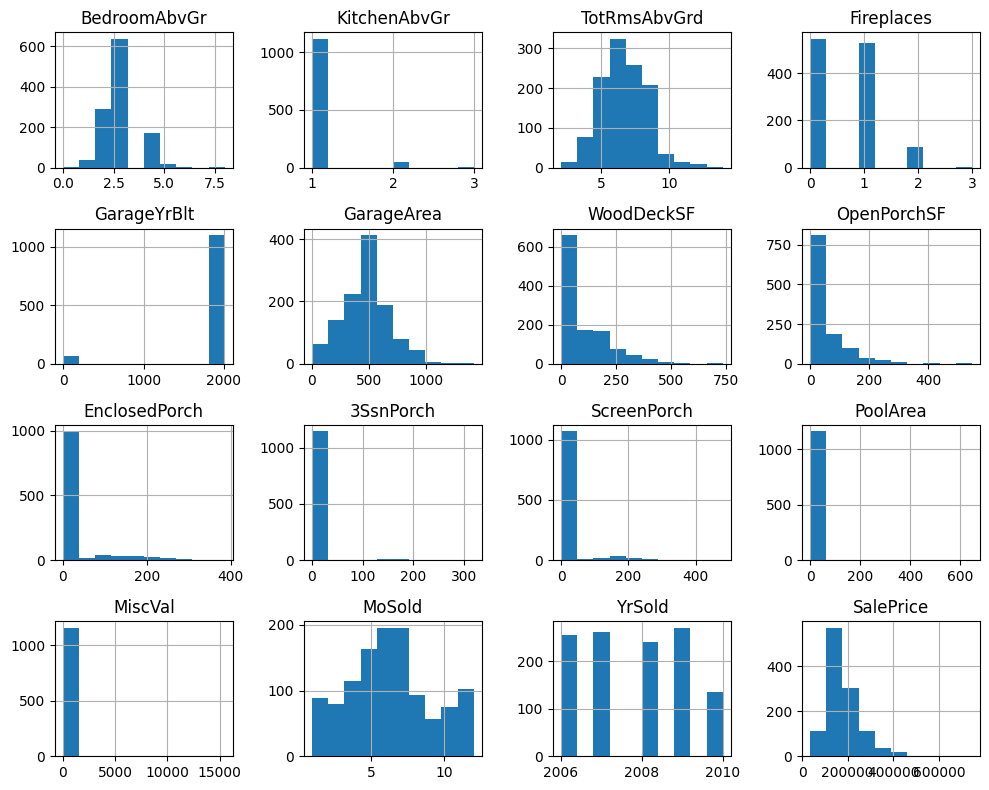

In [23]:
# Histograms for all numerical features
print("\nHistograms of numerical features:")
df.hist(figsize=(10, 8))
plt.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()

Certaines features semble contenir uniquement un seule valeur, ce qui n'est pas le cas.

In [28]:
df["MiscVal"].unique()


array([    0,   400,  1300,   500,   600,   800,  3500,    54,  1150,
        1200, 15500,  2000,  2500,   450,   560,   480,   700,   350,
         620])

In [31]:
df["PoolArea"].unique()

array([  0, 555, 480, 576, 519, 648])


Correlation matrix:


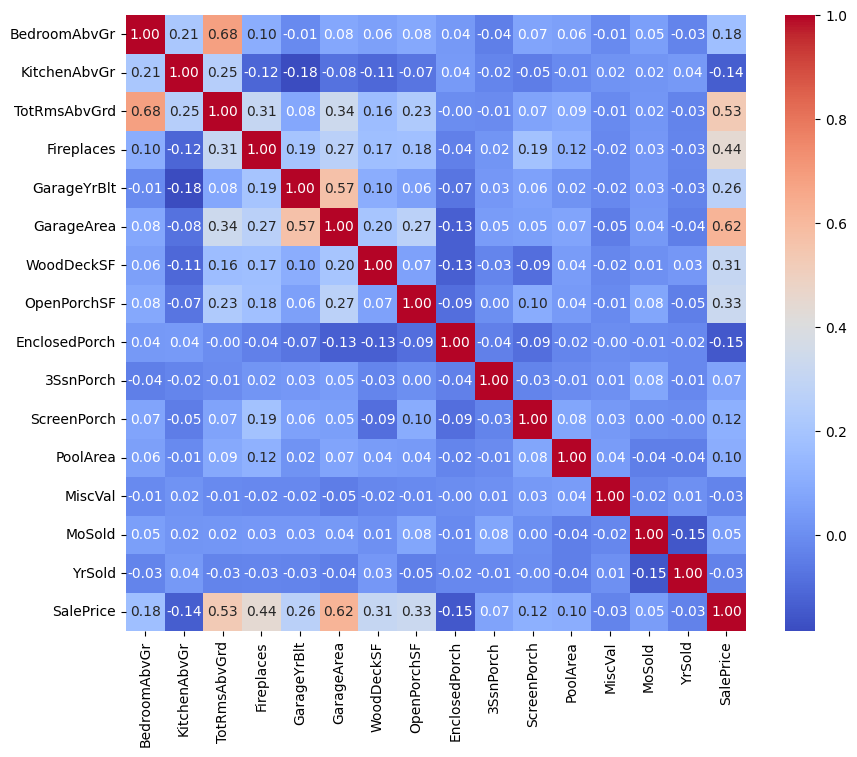

In [40]:
# Correlation matrix
print("\nCorrelation matrix:")
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

Toutes les colonnes sont plus ou moins peu corrélées sauf BedroomAbvGr et TotRmsAbvGrd, ce qui semble logique étant donnée que la plus part des chambres ne sont pas situées au rez de chaussée.


Box plots to check for outliers:


KeyError: 'age'

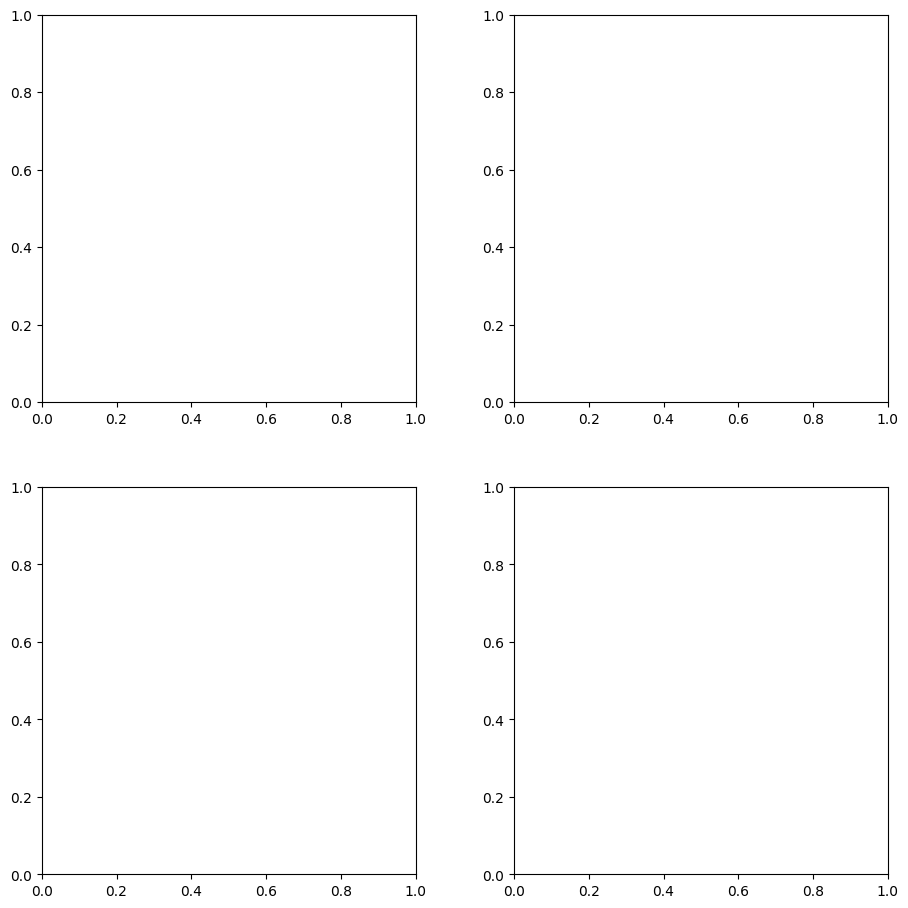

In [63]:
import numpy as np
# Box plots for numerical variables to check outliers
print("\nBox plots to check for outliers:")
numeric_cols = ["age", "sibsp", "parch", "fare"]

# Set up the plot grid
n_cols = 2
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, n_rows*5))
fig.tight_layout(pad=4.0)

for i, col in enumerate(numeric_cols):
    row = i // n_cols
    col_pos = i % n_cols
    sns.boxplot(x=df[col], ax=axes[row, col_pos])
    axes[row, col_pos].set_title(f'Box plot of {col}')

# Remove empty subplots if the number of columns is odd
if len(numeric_cols) % n_cols != 0:
    for j in range(len(numeric_cols), n_rows * n_cols):
        fig.delaxes(axes.flatten()[j])

plt.show()